# NaiveBayes - Email Spam

 Here is a **clean review sheet for Naive Bayes**, based on your notes, with **one realistic dataset/example for each variant** so you know when to use each one.

# Naive Bayes — Complete Review

## 1. The main idea

Naive Bayes is a **supervised classification algorithm** based on Bayes' theorem.

The important assumption is:

> Given the class, the features are conditionally independent of each other.

For example, in spam detection:

```text
Email
 ├── contains "free"
 ├── contains "offer"
 ├── contains "money"
 └── contains "click"
          ↓
       Spam?
```

Naive Bayes treats these features as conditionally independent given the class, even though in real life they may be related.

Despite this "naive" assumption, it works very well for many classification problems, especially **text classification**, and is computationally very fast.

---

# 2. The Naive Bayes family

The main thing to remember is:

| Model             | Type of data                                | Real application                        |
| ----------------- | ------------------------------------------- | --------------------------------------- |
| **GaussianNB**    | Continuous numerical                        | Iris measurements, medical measurements |
| **MultinomialNB** | Counts / frequencies                        | Text classification, spam detection     |
| **ComplementNB**  | Counts / TF-IDF, especially imbalanced text | Imbalanced document classification      |
| **BernoulliNB**   | Binary 0/1 features                         | Word present/absent                     |
| **CategoricalNB** | Categorical features                        | Customer/product categories             |

The choice depends mainly on **what your features represent**.

---

# 3. Gaussian Naive Bayes

### When?

Use it when your features are **continuous numerical values** and approximately Gaussian within each class.

Example:

### Real dataset: Iris

Features:

```text
sepal length
sepal width
petal length
petal width
```

All are continuous numerical measurements.

Goal:

```text
measurements → Iris species
```

The sklearn example in your notes uses exactly this dataset.

### Code

```python
from sklearn.datasets import load_iris
from sklearn.naive_bayes import GaussianNB

X, y = load_iris(return_X_y=True)

model = GaussianNB()

model.fit(X, y)

y_pred = model.predict(X)
```

Think:

```text
Continuous numerical data
          ↓
     GaussianNB
          ↓
      class
```

### Another realistic example

Suppose you have patients:

```text
Age
Blood pressure
Glucose
Cholesterol
BMI
       ↓
Diabetes: Yes / No
```

These are continuous measurements → **GaussianNB can be appropriate**.

---

# 4. Multinomial Naive Bayes

This is one of the most important Naive Bayes variants.

### When?

Use it when your features represent **counts or frequencies**.

The classic example is **text classification**.

Imagine:

```text
Email:
"free money offer"

Word counts:

free    → 1
money   → 1
offer   → 1
click   → 0
meeting → 0
```

Then:

```text
word counts
     ↓
MultinomialNB
     ↓
Spam / Not Spam
```

### Real application

**Spam email classification**

```python
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
```

Usually you first convert text into counts:

```python
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()

X_train_vec = vectorizer.fit_transform(X_train_text)
X_test_vec = vectorizer.transform(X_test_text)

model = MultinomialNB()
model.fit(X_train_vec, y_train)
```

### Think:

> **Multinomial = how many times does each word appear?**

```text
"free free money"

free  = 2
money = 1
```

---

# 5. Complement Naive Bayes

ComplementNB is basically an adaptation of MultinomialNB designed to work particularly well with **imbalanced datasets**, especially text classification.

### Example

Imagine a news classification dataset:

```text
Sports       → 10,000 articles
Politics     →  8,000 articles
Technology   →  7,000 articles
Science      →    500 articles
```

Very imbalanced.

You can try:

```python
from sklearn.naive_bayes import ComplementNB

model = ComplementNB()

model.fit(X_train, y_train)
```

### Why "Complement"?

Instead of estimating a class mainly from documents **inside that class**, ComplementNB also uses information from the **other classes** — the complement of the class.

Conceptually:

```text
Class = Sports

Use information from:
Politics
Technology
Science
        ↓
learn what is NOT Sports
        ↓
classify
```

The sklearn documentation notes that ComplementNB is particularly suited to imbalanced datasets and can outperform MultinomialNB on text classification tasks.

### Remember

```text
MultinomialNB
       ↓
text/counts

ComplementNB
       ↓
text/counts + particularly useful for imbalance
```

---

# 6. Bernoulli Naive Bayes

This one is very easy to understand.

### When?

When your features are **binary**:

```text
0 = absent
1 = present
```

The notes specifically describe each feature as a binary-valued variable.

### Example: spam detection

Instead of counting words:

```text
free = 3
money = 2
offer = 1
```

we only care whether the word exists:

```text
free   = 1
money  = 1
offer  = 1
meeting = 0
```

So:

```text
             free money offer meeting
Email 1       1     1      1      0
Email 2       0     0      0      1
Email 3       1     0      1      0
```

Then:

```python
from sklearn.naive_bayes import BernoulliNB

model = BernoulliNB()

model.fit(X_train, y_train)
```

### Key difference

**Multinomial:**

> How many times did the word appear?

**Bernoulli:**

> Did the word appear or not?

```text
Multinomial:
free = 5

Bernoulli:
free = 1
```

The notes also mention that BernoulliNB can be useful for shorter documents.

---

# 7. Categorical Naive Bayes

### When?

When your features themselves are **categorical**.

For example, customer data:

```text
Age group      = Young / Adult / Senior
Browser        = Chrome / Safari / Firefox
Subscription   = Basic / Premium
Country        = Turkey / Iran / USA / ...
```

Target:

```text
Will purchase?
Yes / No
```

These aren't naturally continuous numbers.

You can encode them:

```text
Chrome  → 0
Safari  → 1
Firefox → 2
```

and use:

```python
from sklearn.naive_bayes import CategoricalNB

model = CategoricalNB()

model.fit(X_train, y_train)
```

The important thing is that each feature has its own categorical distribution conditioned on the class.

### Think:

```text
Categorical features
        ↓
CategoricalNB
        ↓
classification
```

---

# 8. The easiest way to choose

This is probably the most useful part to memorize:

### Ask: **What does one feature represent?**

```text
                    What is my feature?
                           │
             ┌─────────────┼─────────────┐
             ↓             ↓             ↓
       Continuous       Count          Binary
        numerical       /frequency      0/1
             ↓             ↓             ↓
       GaussianNB    MultinomialNB   BernoulliNB
```

And:

```text
Categorical values
        ↓
CategoricalNB
```

If your data is **text + imbalanced classes**:

```text
Text + imbalance
       ↓
ComplementNB
```

---

# 9. One real-world example for each

| Model             | Dataset example                | Features                            | Target                 |
| ----------------- | ------------------------------ | ----------------------------------- | ---------------------- |
| **GaussianNB**    | Iris                           | Sepal/petal measurements            | Species                |
| **MultinomialNB** | SpamAssassin / SMS spam        | Word counts / TF-IDF                | Spam / Ham             |
| **ComplementNB**  | Imbalanced news classification | Word counts / TF-IDF                | News category          |
| **BernoulliNB**   | SMS spam                       | Word present/absent                 | Spam / Ham             |
| **CategoricalNB** | Customer purchase data         | Country, browser, subscription type | Purchase / No purchase |

---

# 10. One thing you should NOT forget

Naive Bayes does **not** require you to manually calculate all the probabilities.

You normally do:

```python
model = GaussianNB()
model.fit(X_train, y_train)
model.predict(X_test)
```

or:

```python
model = MultinomialNB()
model.fit(X_train, y_train)
model.predict(X_test)
```

The main thing you need to understand is **which probability/distribution assumption matches your data**.

Also, the probabilities returned by `predict_proba()` should not be interpreted as highly accurate calibrated probabilities; the notes explicitly warn that Naive Bayes is generally a relatively poor probability estimator despite being a useful classifier.

### 🧠 Final memory trick

```text
Gaussian     → continuous measurements
Multinomial  → word COUNTS
Bernoulli    → word EXISTS? 0/1
Categorical  → categories
Complement   → Multinomial + imbalanced text
```

And for your **ML/bioinformatics direction**, a particularly relevant application is:

```text
Biomedical text / abstracts
        ↓
TF-IDF / word counts
        ↓
MultinomialNB or ComplementNB
        ↓
Disease / topic / document classification
```

while for ordinary continuous biological measurements:

```text
Gene/protein measurements
        ↓
continuous features
        ↓
GaussianNB
        ↓
classification
```


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from flax.experimental.nnx.docs.quick_start import X_train

from sklearn.naive_bayes import MultinomialNB, ComplementNB, BernoulliNB
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split,StratifiedKFold,cross_validate,GridSearchCV
from sklearn.metrics import accuracy_score,classification_report,consensus_score,precision_score,recall_score,f1_score,roc_curve

In [4]:
ENRON_URL = 'https://raw.githubusercontent.com/MWiechmann/enron_spam_data/master/enron_spam_data.zip'
SMS_URL = 'https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv'



In [5]:
ENRON_URL

'https://raw.githubusercontent.com/MWiechmann/enron_spam_data/master/enron_spam_data.zip'

In [6]:
SMS_URL

'https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv'

In [36]:
df = pd.read_csv('enron_spam_data.csv')

In [37]:
df

,Message ID,Subject,Message,Spam/Ham,Date
0,0,christmas tree farm pictures,NaN,ham,1999-12-10
1,1,"vastar resources , inc .","gary , production from the high island larger ...",ham,1999-12-13
2,2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,1999-12-14
3,3,re : issue,fyi - see note below - already done .\nstella\...,ham,1999-12-14
4,4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14
...,...,...,...,...,...
33711,33711,= ? iso - 8859 - 1 ? q ? good _ news _ c = eda...,"hello , welcome to gigapharm onlinne shop .\np...",spam,2005-07-29
33712,33712,all prescript medicines are on special . to be...,i got it earlier than expected and it was wrap...,spam,2005-07-29
33713,33713,the next generation online pharmacy .,are you ready to rock on ? let the man in you ...,spam,2005-07-30
33714,33714,bloow in 5 - 10 times the time,learn how to last 5 - 10 times longer in\nbed ...,spam,2005-07-30


In [38]:
y = df['Spam/Ham']
X = df[["Subject","Message"]]

In [39]:
X

,Subject,Message
0,christmas tree farm pictures,NaN
1,"vastar resources , inc .","gary , production from the high island larger ..."
2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc
3,re : issue,fyi - see note below - already done .\nstella\...
4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...
...,...,...
33711,= ? iso - 8859 - 1 ? q ? good _ news _ c = eda...,"hello , welcome to gigapharm onlinne shop .\np..."
33712,all prescript medicines are on special . to be...,i got it earlier than expected and it was wrap...
33713,the next generation online pharmacy .,are you ready to rock on ? let the man in you ...
33714,bloow in 5 - 10 times the time,learn how to last 5 - 10 times longer in\nbed ...


In [40]:
y

0         ham
1         ham
2         ham
3         ham
4         ham
         ... 
33711    spam
33712    spam
33713    spam
33714    spam
33715    spam
Name: Spam/Ham, Length: 33716, dtype: str

<BarContainer object of 2 artists>

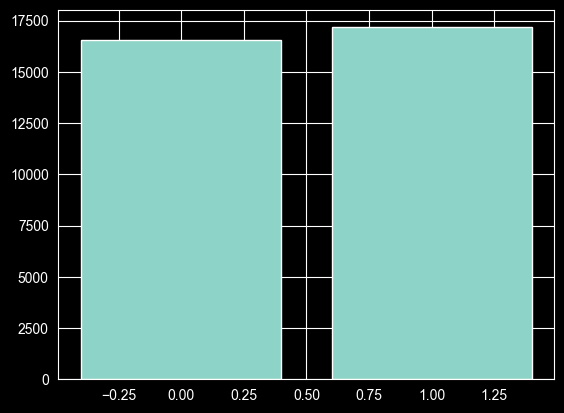

In [41]:
dist = np.unique(y,return_counts=True)
plt.bar(range(len(dist[0])),dist[1])

In [42]:
X_train,X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [44]:
X_train.shape,y_train.shape,X_test.shape,y_test.shape

((26972, 2), (26972,), (6744, 2), (6744,))

In [45]:
X_train["text"] = X_train["Subject"].fillna("") + " " + X_train["Message"].fillna("")
X_test["text"] = X_test["Subject"].fillna("") + " " + X_test["Message"].fillna("")

In [46]:
X_train = X_train["text"]
X_test = X_test["text"]

In [50]:
X_train[2]

'calpine daily gas nomination - calpine daily gas nomination 1 . doc'

In [52]:
vectorizer = CountVectorizer(
    lowercase=True,
    stop_words="english",
    min_df=2
)

In [54]:
pipe = Pipeline([
    ("vectorizer", vectorizer),
    ("model", MultinomialNB())
])
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('vectorizer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"stop_words stop_words: {'english'}, list, default=NoneIf 'english', a built-in stop word list for English is used.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"min_df min_df: float in range [0.0, 1.0] or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float, the parameter represents a proportion of documents, integerabsolute counts.This parameter is ignored if vocabulary is not None.",2
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a sligh

In [55]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('vectorizer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[<U4](2,)","['ham','spam']"
,"stop_words stop_words: {'english'}, list, default=NoneIf 'english', a built-in stop word list for English is used.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"min_df min_df: float in range [0.0, 1.0] or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float, the parameter represents a proportion of documents, integerabsolute counts.This parameter is ignored if vocabulary is not None.",2
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'


In [57]:
y_pred = pipe.predict(X_test)

In [59]:
y_pred[0]

'spam'

In [61]:
y_test.iloc[0]

'spam'

In [62]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         ham       0.99      0.99      0.99      3276
        spam       0.99      0.99      0.99      3468

    accuracy                           0.99      6744
   macro avg       0.99      0.99      0.99      6744
weighted avg       0.99      0.99      0.99      6744



In [63]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

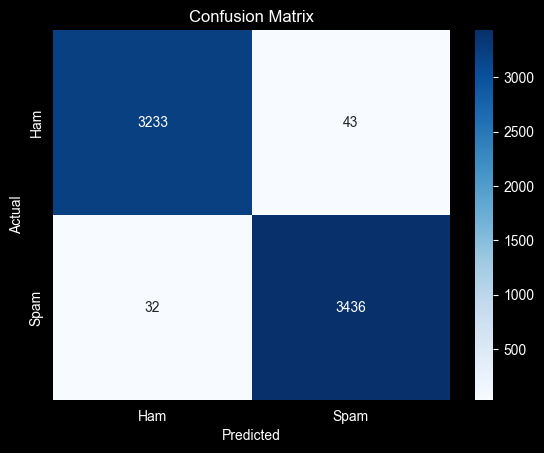

In [67]:
sns.heatmap(
    cm,
    cmap="Blues",
    annot=True,
    fmt="g",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [68]:
## ROC
y_prob = pipe.predict_proba(X_test)

In [69]:
y_prob

array([[2.34899481e-57, 1.00000000e+00],
       [1.00000000e+00, 1.64821796e-10],
       [1.81243407e-28, 1.00000000e+00],
       ...,
       [1.00000000e+00, 1.96683232e-23],
       [1.00000000e+00, 1.09801167e-12],
       [6.66833302e-71, 1.00000000e+00]])

In [78]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import roc_curve,auc

In [79]:
encoder = OneHotEncoder()

encoder.fit(y_test.to_numpy().reshape(-1, 1))

y_test_s = encoder.transform(
    y_test.to_numpy().reshape(-1, 1)
)

In [84]:
y_test_s = encoder.transform(
    y_test.to_numpy().reshape(-1, 1)
).toarray()

print(y_test_s)

[[0. 1.]
 [1. 0.]
 [0. 1.]
 ...
 [1. 0.]
 [1. 0.]
 [0. 1.]]


In [85]:
y_test_ham = y_test_s[:, 0]
y_test_spam = y_test_s[:, 1]

In [88]:
y_test_s

array([[0., 1.],
       [1., 0.],
       [0., 1.],
       ...,
       [1., 0.],
       [1., 0.],
       [0., 1.]])

In [91]:
y_prob

array([[2.34899481e-57, 1.00000000e+00],
       [1.00000000e+00, 1.64821796e-10],
       [1.81243407e-28, 1.00000000e+00],
       ...,
       [1.00000000e+00, 1.96683232e-23],
       [1.00000000e+00, 1.09801167e-12],
       [6.66833302e-71, 1.00000000e+00]])

In [94]:
classes = encoder.categories_[0]
classes

array(['ham', 'spam'], dtype=object)

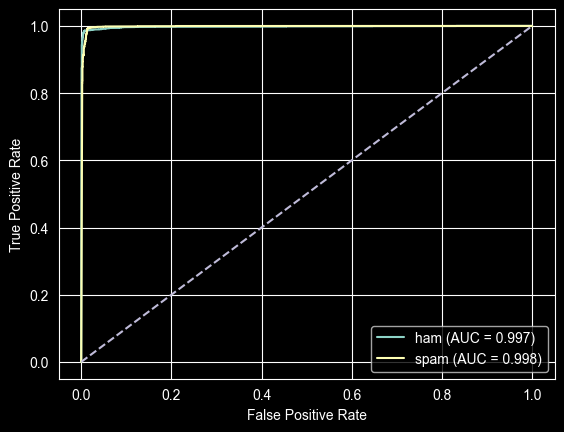

In [98]:
from sklearn.metrics import roc_auc_score
for i in range(2):
    fpr, tpr, _ = roc_curve(y_test_s[:, i], y_prob[:, i])
    auc = roc_auc_score(y_test_s[:, i], y_prob[:, i])

    plt.plot(fpr, tpr, label=f"{classes[i]} (AUC = {auc:.3f})")

plt.legend()
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.plot([0, 1], [0, 1], '--')
plt.show()


In [101]:
## Compare with ComplementNB

In [102]:
from sklearn.naive_bayes import ComplementNB

complement_pipe = Pipeline([
    ("vectorizer", CountVectorizer(
        lowercase=True,
        stop_words="english",
        min_df=2
    )),
    ("model", ComplementNB())
])

complement_pipe.fit(X_train, y_train)

y_pred_complement = complement_pipe.predict(X_test)

print(classification_report(y_test, y_pred_complement))

              precision    recall  f1-score   support

         ham       0.98      0.99      0.99      3276
        spam       0.99      0.99      0.99      3468

    accuracy                           0.99      6744
   macro avg       0.99      0.99      0.99      6744
weighted avg       0.99      0.99      0.99      6744



In [104]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    pipe,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

print(scores)
print("Mean F1:", scores.mean())
print("Std:", scores.std())

C:\Users\top\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py:974: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\top\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_scorer.py", line 167, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "C:\Users\top\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_scorer.py", line 455, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "C:\Users\top\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_scorer.py", line 97, in _cached_call
    result, _ = _get_response_values(
                ^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\top\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\_response.py", line 208, in _get_response_values
    raise Va

[nan nan nan nan nan]
Mean F1: nan
Std: nan


C:\Users\top\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py:974: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\top\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_scorer.py", line 167, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "C:\Users\top\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_scorer.py", line 455, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "C:\Users\top\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_scorer.py", line 97, in _cached_call
    result, _ = _get_response_values(
                ^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\top\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\_response.py", line 208, in _get_response_values
    raise Va